# 02 · Distribution fitting

Use the Kamp at Zwettl inputs to compare candidate distributions before a focused Bayesian analysis.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Fifteen candidate distributions
The four saved `Fit - ...` alternatives compare 1951–2001 and 1951–2005, each with and without temporal expansion.
The candidate table keeps unsuccessful fits and their messages visible; plotted curves include only successful candidates whose app `ShowResults` setting is selected.
AIC/BIC rank candidates only **within one saved fitting alternative**, where observations and likelihood treatment are the same.
The four fitting alternatives use different periods or historical-information treatments, so their scores are not ranked across inputs.
A favorable within-input score alone does not establish a plausible rare tail.

,Setting,Saved choice
0,Analysis,FittingAnalysis
1,InputData,Systematic (1951-2001)


,Distribution,Succeeded,Shown,AIC,BIC,RMSE,Failure
8,Log-Normal (base e),True,True,476.865750,480.729401,4.134752,
10,Log-Normal (base 10),True,True,476.865750,480.729401,4.136133,
5,Generalized Pareto,True,True,477.515370,483.310847,5.562598,
13,Pearson Type III,True,True,477.691944,483.487421,4.131025,
1,Gamma,True,True,477.872561,481.736212,5.659434,
6,Gumbel (EVI),True,True,478.118149,481.981801,5.945565,
11,Log-Pearson Type III,True,True,478.796546,484.592023,4.492208,
4,Generalized Normal,True,True,478.865191,484.660668,4.200849,
7,Kappa-4,True,True,478.977015,486.704318,4.971882,
2,Generalized Extreme Value,True,True,479.425110,485.220587,4.455896,


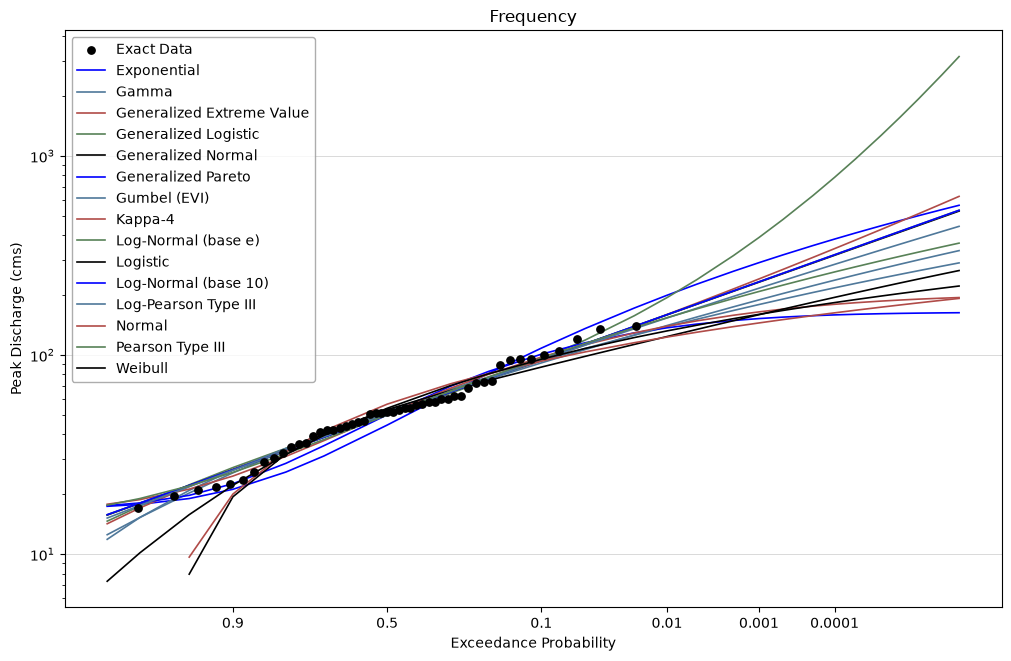

,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Fit - Systematic (1951-2001),saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
1,Fit - Systematic (1951-2005),saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
2,Fit - Systematic (1951-2001) + Temporal Expansion,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
3,Fit - Systematic (1951-2005) + Temporal Expansion,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


In [2]:
PROJECT = "viglione-et-al-2013"
names = ["Fit - Systematic (1951-2001)", "Fit - Systematic (1951-2005)",
         "Fit - Systematic (1951-2001) + Temporal Expansion", "Fit - Systematic (1951-2005) + Temporal Expansion"]
fits = [saved_case(PROJECT, name, run=RUN_ANALYSES) for name in names]
display(fits[0].settings)
display(fits[0].candidates.sort_values("AIC", na_position="last"))
fits[0].show("frequency")
display(case_provenance(fits))

## Inspect fit in more than one view
The density view emphasizes the body of the sample; the frequency view emphasizes the upper tail.
P–P and Q–Q plots use the app's nonparametric plotting positions, preserving the historical input treatment.
CDF, P–P, Q–Q and every candidate overlay are also available in the separate plot gallery.

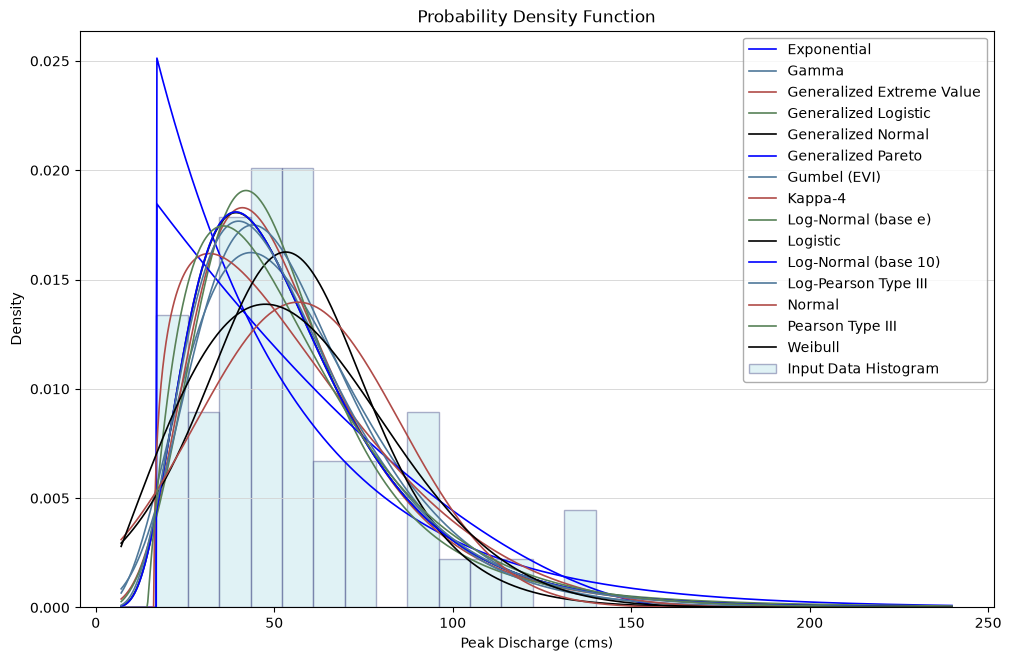

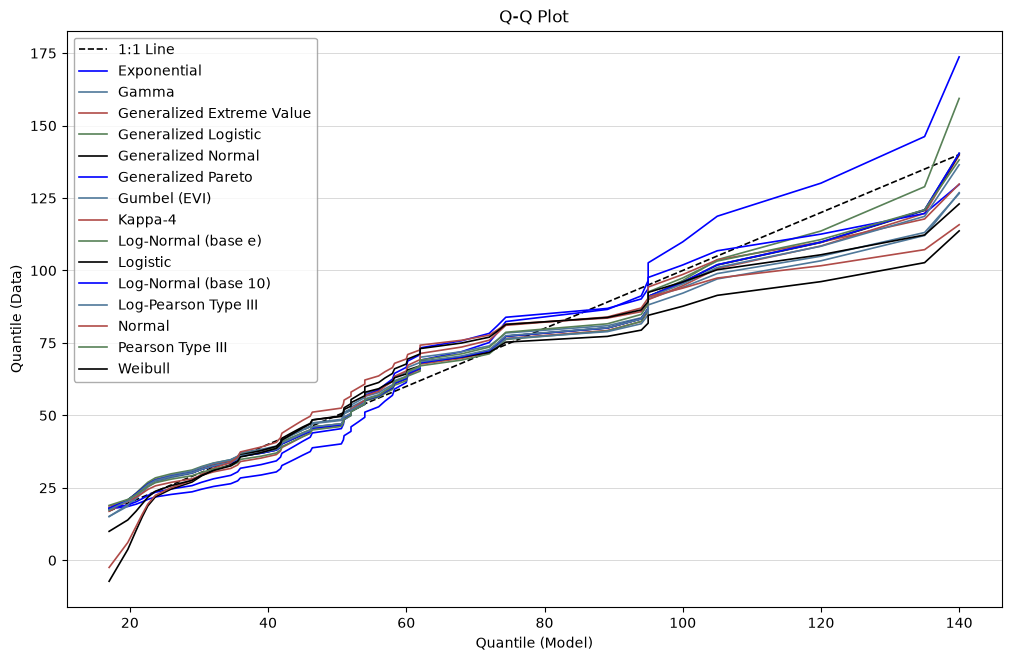

,Distribution,Succeeded,Shown,AIC,BIC,RMSE,Failure,Input
8,Log-Normal (base e),True,True,476.865750,480.729401,4.134752,,Fit - Systematic (1951-2001)
10,Log-Normal (base 10),True,True,476.865750,480.729401,4.136133,,Fit - Systematic (1951-2001)
5,Generalized Pareto,True,True,477.515370,483.310847,5.562598,,Fit - Systematic (1951-2001)
40,Log-Normal (base 10),True,True,508.840792,516.833696,18.900618,,Fit - Systematic (1951-2001) + Temporal Expansion
38,Log-Normal (base e),True,True,508.840793,516.833697,18.900169,,Fit - Systematic (1951-2001) + Temporal Expansion
30,Exponential,True,True,509.110727,517.103631,15.830746,,Fit - Systematic (1951-2001) + Temporal Expansion
18,Generalized Logistic,True,True,530.989242,537.011242,33.845285,,Fit - Systematic (1951-2005)
22,Kappa-4,True,True,531.463755,539.493087,37.348757,,Fit - Systematic (1951-2005)
17,Generalized Extreme Value,True,True,531.985769,538.007768,35.340353,,Fit - Systematic (1951-2005)
49,Generalized Normal,True,True,561.339450,573.358510,18.243240,,Fit - Systematic (1951-2005) + Temporal Expansion


In [3]:
fits[0].show("pdf")
fits[0].show("qq")
display(pd.concat([fit.candidates.assign(Input=fit.data["name"]) for fit in fits], ignore_index=True)
        .sort_values(["Input", "AIC"]).groupby("Input", sort=False).head(3))

**Interpretation:** changing the observation period or adding historical bounds changes the evidence. Notebook 03 holds the GEV model family fixed to examine those information sources directly.